In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv('/content/Social_Network_Ads.csv')
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [3]:
x=df.drop('Purchased', axis=1)
y=df['Purchased']

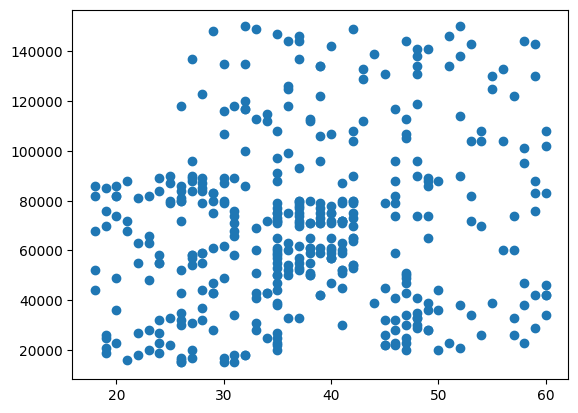

In [8]:
plt.scatter(df['Age'], df['EstimatedSalary'])

In [9]:
model=Sequential()

model.add(Dense(128, activation='relu', input_dim=2))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(loss='binary_crossentropy',optimizer='adam', metrics=['accuracy'])

In [13]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2)

In [14]:
hist=model.fit(x_train, y_train, validation_data=(x_test,y_test), epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.6094 - loss: 1184.0118 - val_accuracy: 0.4250 - val_loss: 516.7390
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4656 - loss: 347.2477 - val_accuracy: 0.5750 - val_loss: 301.1396
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5281 - loss: 126.6319 - val_accuracy: 0.5750 - val_loss: 321.9946
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5031 - loss: 121.2876 - val_accuracy: 0.5750 - val_loss: 158.7008
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.5531 - loss: 62.5719 - val_accuracy: 0.4250 - val_loss: 22.8427
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5188 - loss: 28.1141 - val_accuracy: 0.5750 - val_loss: 69.0895
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5375 - loss: 64.5393 - val_accuracy: 0.4250 - val_loss: 38.7476
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5031 - loss: 65.7

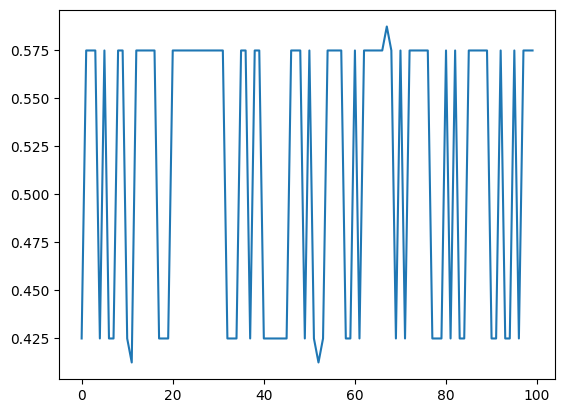

In [15]:
plt.plot(hist.history['val_accuracy'])

Now what we need to do -- we need to normailze/Standardize our data (Standard Scaler)

In [16]:
from sklearn.preprocessing import StandardScaler

ss=StandardScaler()
xtrain=ss.fit_transform(x_train)
xtest=ss.transform(x_test)

In [18]:
model2=Sequential()

model2.add(Dense(128, activation='relu', input_dim=2))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(loss='binary_crossentropy',optimizer='adam', metrics=['accuracy'])

hist2=model2.fit(xtrain, y_train, validation_data=(xtest,y_test), epochs=100)



Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6469 - loss: 0.6770 - val_accuracy: 0.6500 - val_loss: 0.6539
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7375 - loss: 0.6225 - val_accuracy: 0.7750 - val_loss: 0.5962
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7812 - loss: 0.5762 - val_accuracy: 0.7875 - val_loss: 0.5501
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7969 - loss: 0.5349 - val_accuracy: 0.8000 - val_loss: 0.5137
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8281 - loss: 0.5002 - val_accuracy: 0.8250 - val_loss: 0.4830
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8406 - loss: 0.4701 - val_accuracy: 0.8125 - val_loss: 0.4564
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8469 - loss: 0.4424 - val_accuracy: 0.8125 - val_loss: 0.4337
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8500 - loss: 0.4179 - val_accuracy: 0.8125 -

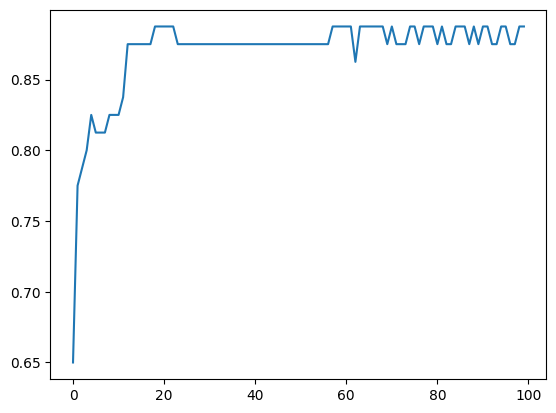

In [19]:
plt.plot(hist2.history['val_accuracy'])